# Продажи автомобилей в Казахстане

Кислицын Дмитрий Геннадьевич, М26-555

Курсовая работа за январь — сентябрь 2019 года. Подготовлю данные и сравню «Меркур Авто» с внутренним рынком.

После очистки в выборке осталось 21 268 строк. Внутренний рынок — 34 725 автомобилей с учётом возврата. «Меркур Авто» продал 394 автомобиля, его доля — 1,13%. Средняя выручка на автомобиль у автоцентра выше рыночной, но это не показатель прибыли.

Исходник: [материалы задания](https://disk.yandex.ru/d/OmlexqoVSR6mwg). Файл `autokz2019.csv` должен лежать рядом с ноутбуком и `clean_data.py`. Для запуска нужны pandas, numpy и matplotlib.

## 1 Загрузка и осмотр

Строка может описывать одну машину или несколько. Объём продаж считаю по столбцу количества, денежные показатели — в долларах США. Средний чек здесь означает выручку на автомобиль, а не размер отдельного договора.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from clean_data import clean_data

%matplotlib inline
pd.set_option('display.max_columns', 18)
pd.set_option('display.float_format', lambda value: f'{value:,.2f}')
plt.rcParams.update({'figure.figsize': (10, 4.5), 'font.family': 'DejaVu Sans', 'font.size': 11})
blue, orange = '#426789', '#c07836'

raw = pd.read_csv('autokz2019.csv', sep=';', decimal=',', low_memory=False)
print('Размер исходной таблицы:', raw.shape)
display(raw.head(3))

Размер исходной таблицы: (39966, 25)


,Год,Месяц,Компания,Бренд,Модель,Модификация,Год выпуска,Страна-производитель,Вид топлива,...,Форма расчета,Количество,"Цена, USD","Продажа, USD",Область,Сегментация 2013,Класс 2013,Сегментация Eng,Локализация производства
0,2019,Май,Mercur Auto,Audi,A3,TFSI,2018,Германия,Бензин,...,безналичный,1.00,"28,115.00","28,115.00",г.Алматы,Легковые автомобили,C класс,C,Импорт
1,2019,Август,Mercur Auto,Audi,A3,TFSI,2018,Германия,Бензин,...,наличный,1.00,"32,246.99","32,246.99",г.Алматы,Легковые автомобили,C класс,C,Импорт
2,2019,Апрель,Mercur Auto,Audi,A4,TFSI,2018,Германия,Бензин,...,безналичный,1.00,"32,000.00","32,000.00",г.Алматы,Легковые автомобили,D класс,D,Импорт


In [2]:
inspection = pd.DataFrame({'Тип': raw.dtypes.astype(str), 'Пропуски': raw.isna().sum()})
display(inspection)
print('Полностью пустые строки:', raw.isna().all(axis=1).sum())
print('Полные дубликаты:', raw.duplicated().sum())

,Тип,Пропуски
Год,int64,0
Месяц,str,0
Компания,str,0
Бренд,str,0
Модель,str,0
Модификация,str,3591
Год выпуска,str,501
Страна-производитель,str,0
Вид топлива,str,3140
"Объём двиг, л,",str,4258


Полностью пустые строки: 0
Полные дубликаты: 18698


## 2 Очистка

В `clean_data.py` собраны все преобразования. Дубликаты ищу по полной исходной записи до удаления столбцов. Это важно: две записи могут различаться дилером или модификацией. После нормализации похожие строки повторно не удаляю.

Убираю семь столбцов по условию, пробелы и неявные дубли в названиях компаний. Страны перевожу в ALPHA-3, топливо — в F, D, E, HYB, привод — в FWD, RWD, 4WD и 2WD. По 2WD нельзя определить переднюю или заднюю ось, поэтому сохраняю отдельную категорию.

У 27 Renault сдвинулись топливо, объём и коробка. Возвращаю значения на место; топливо восстанавливаю по однозначным аналогам с той же маркой, моделью и объёмом. Это предположение на основе выборки. У Niva ошибочный ряд объёмов заменяю на 1,7 л, у одного Polo — на 1,6 л по записям той же модификации. Для электромобилей объём ДВС равен нулю: 400 л.с. и 88 kWh не являются литрами. E-Hybrid у четырёх Porsche учитываю как HYB.

Роботы, вариаторы и редуктор электромобиля входят в категорию «Автомат». Неопределённые характеристики оставляю пустыми, а не заполняю средним значением. Шесть пропусков количества восстанавливаю как ноль: цена положительная, выручка нулевая. Возврат и оптовые продажи сохраняю.

In [3]:
df = clean_data('autokz2019.csv')
display(df.head(3))
display(pd.DataFrame({'Тип': df.dtypes.astype(str), 'Пропуски': df.isna().sum()}))

Исходные данные: 39966 строк, 25 столбцов

Удалено пустых строк: 0, полных дубликатов: 18698


Исправлено строк со сдвигом полей Renault: 27
Исправлен объём двигателя: Niva — 25, Polo — 1
Топливо восстановлено по однозначным аналогам: 38
Готовые данные: 21268 строк, 17 столбцов


,company,brand,model,manufacture_year,country,fuel_type,engine_volume,transmission,drive_type,region,quantity,price_usd,revenue_usd,area,segment_2013,class_2013,sale_date
0,Меркур Авто,Audi,A3,2018,DEU,F,1.40,Автомат,FWD,Алматы,1,"28,115.00","28,115.00",г. Алматы,Легковые автомобили,C класс,2019-05-31
1,Меркур Авто,Audi,A3,2018,DEU,F,1.40,Автомат,FWD,Алматы,1,"32,246.99","32,246.99",г. Алматы,Легковые автомобили,C класс,2019-08-31
2,Меркур Авто,Audi,A4,2018,DEU,F,1.40,Автомат,FWD,Алматы,1,"32,000.00","32,000.00",г. Алматы,Легковые автомобили,D класс,2019-04-30


,Тип,Пропуски
company,str,0
brand,str,0
model,str,0
manufacture_year,Int64,233
country,str,0
fuel_type,category,1879
engine_volume,float64,2295
transmission,category,1889
drive_type,category,2294
region,str,0


### Проверка результата

Проверю даты, категории и соответствие выручки цене и количеству. CSV хранит значения, но не типы pandas. При повторном чтении типы datetime и category нужно задать снова.

In [4]:
assert len(df) == len(raw.dropna(how='all').drop_duplicates())
assert df['sale_date'].dt.is_month_end.all()
assert df['quantity'].notna().all()
assert df['country'].str.fullmatch(r'[A-Z]{3}').all()
assert set(df['fuel_type'].dropna()) <= {'F', 'D', 'E', 'HYB'}
assert set(df['transmission'].dropna()) <= {'Автомат', 'Механика'}
assert set(df['drive_type'].dropna()) <= {'FWD', 'RWD', '4WD', '2WD'}
for column in ['fuel_type', 'transmission', 'drive_type', 'segment_2013', 'class_2013']:
    assert isinstance(df[column].dtype, pd.CategoricalDtype)
error = (df['revenue_usd'] - df['price_usd'] * df['quantity']).abs()
assert error.max() < 0.01
print('Максимальное расхождение выручки и цены × количества:', round(error.max(), 4), 'USD')
print('Диапазон дат:', df['sale_date'].min().date(), '—', df['sale_date'].max().date())
display(df.loc[df['quantity'] < 0, ['brand', 'model', 'quantity', 'revenue_usd']])
display(df.nlargest(5, 'quantity')[['brand', 'model', 'quantity', 'revenue_usd']])

df.to_csv('autokz2019_clean.csv', index=False, encoding='utf-8-sig', date_format='%Y-%m-%d')
reloaded = pd.read_csv('autokz2019_clean.csv', parse_dates=['sale_date'])
assert reloaded.shape == df.shape
assert reloaded['quantity'].sum() == df['quantity'].sum()
assert np.isclose(reloaded['revenue_usd'].sum(), df['revenue_usd'].sum())
print('CSV сохранён и повторно прочитан')

Максимальное расхождение выручки и цены × количества: 0.0007 USD
Диапазон дат: 2019-01-31 — 2019-09-30


,brand,model,quantity,revenue_usd
15144,Skoda,Superb,-1,"-35,588.25"


,brand,model,quantity,revenue_usd
8870,Lada,4x4,115,"1,035,000.00"
14974,Skoda,Octavia,100,"1,870,000.00"
20312,Volkswagen,Polo,79,"1,261,459.99"
7341,Jac,S3,70,"1,092,976.75"
8953,Lada,4x4,66,"594,000.00"


CSV сохранён и повторно прочитан


## 3 Исследовательский анализ

В CSV есть экспорт. Сохраню его для других задач, но внутренний рынок буду считать отдельно. Для распределений беру положительные количества: возврат не является новой покупкой. Объём рынка и долю автоцентра считаю с учётом возврата.

In [5]:
export = df[df['region'] == 'Экспорт']
market = df[df['region'] != 'Экспорт'].copy()
mercur = market[market['company'] == 'Меркур Авто'].copy()
sales = market[market['quantity'] > 0].copy()
print(f'Экспорт: {len(export)} строк, {export.quantity.sum():,} автомобилей, {export.revenue_usd.sum():,.2f} USD')
print(f'Внутренний рынок: {len(market)} строк, {market.quantity.sum():,} автомобилей, {market.revenue_usd.sum():,.2f} USD')
print(f'Продажи до вычета возврата: {sales.quantity.sum():,} автомобилей')

Экспорт: 331 строк, 440 автомобилей, 13,481,721.22 USD
Внутренний рынок: 20937 строк, 34,725 автомобилей, 801,697,865.97 USD
Продажи до вычета возврата: 34,726 автомобилей


### Цена и объём двигателя

Гистограммы учитывают количество машин в строке. У дорогих автомобилей может быть небольшой объём продаж, поэтому средняя цена без весов была бы завышена.

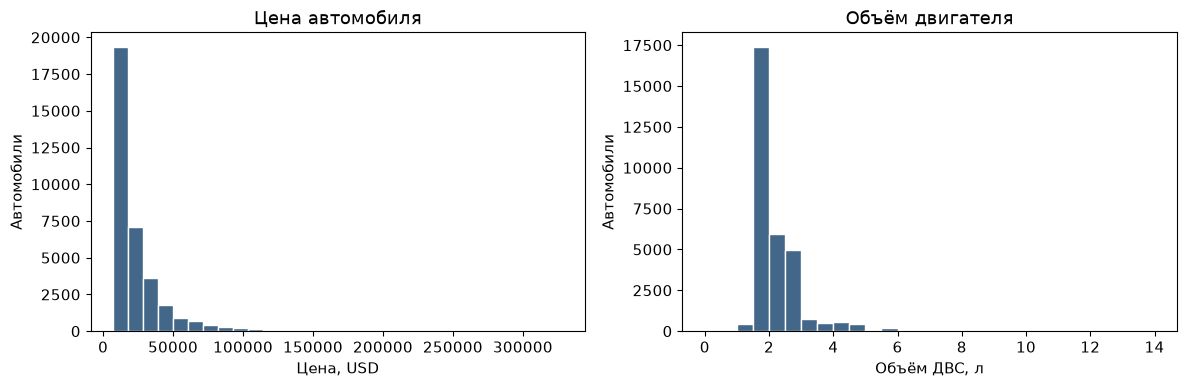

Средняя выручка на проданный автомобиль: 23087.41 USD
Без сведений об объёме: 3322 автомобилей
Максимальная цена: 328510.97 USD


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(sales['price_usd'], bins=30, weights=sales['quantity'].astype(float), color=blue, edgecolor='white')
axes[0].set(title='Цена автомобиля', xlabel='Цена, USD', ylabel='Автомобили')
axes[0].ticklabel_format(style='plain', axis='x')
engine_sales = sales.dropna(subset=['engine_volume'])
axes[1].hist(engine_sales['engine_volume'], bins=np.arange(0, 14.5, 0.5), weights=engine_sales['quantity'].astype(float), color=blue, edgecolor='white')
axes[1].set(title='Объём двигателя', xlabel='Объём ДВС, л', ylabel='Автомобили')
plt.tight_layout()
plt.show()

print('Средняя выручка на проданный автомобиль:', round(sales.revenue_usd.sum() / sales.quantity.sum(), 2), 'USD')
print('Без сведений об объёме:', sales.loc[sales.engine_volume.isna(), 'quantity'].sum(), 'автомобилей')
print('Максимальная цена:', round(sales.price_usd.max(), 2), 'USD')

Большая часть автомобилей находится в нижней части диапазона цен. Дорогие модели образуют длинный правый хвост. В объёмах двигателя есть крупные значения у коммерческого транспорта, поэтому не удаляю их как ошибки только по размеру.

,Автомобили
manufacture_year,
2011,1
2013,1
2014,2
2016,29
2017,206
2018,7258
2019,26340
<NA>,889


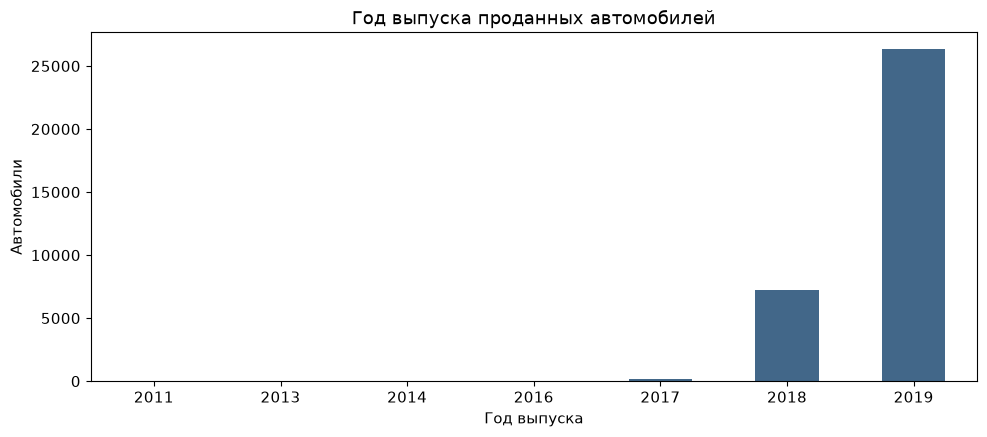

Доля автомобилей 2019 года среди всех продаж: 75.85 %


In [7]:
years = sales.groupby('manufacture_year', dropna=False)['quantity'].sum()
display(years.to_frame('Автомобили'))
known_years = sales.dropna(subset=['manufacture_year']).groupby('manufacture_year')['quantity'].sum()
ax = known_years.rename(index=lambda year: str(int(year))).plot.bar(color=blue, rot=0)
ax.set(title='Год выпуска проданных автомобилей', xlabel='Год выпуска', ylabel='Автомобили')
plt.tight_layout()
plt.show()
print('Доля автомобилей 2019 года среди всех продаж:', round(sales.loc[sales.manufacture_year == 2019, 'quantity'].sum() / sales.quantity.sum() * 100, 2), '%')

### Бренды и модели

,Автомобили
brand,
Lada,11085
Hyundai,4987
Toyota,3636
Kia,2346
Nissan,1651
GAZ,1361
UAZ,1217
Renault,1193
Volkswagen,1048


Автомобили
brand      model             
Lada       Granta        3663
           Vesta         2650
           4x4           2469
           Largus        1682
Hyundai    Tucson        1370
           Accent        1246
Toyota     Camry         1120
Hyundai    Creta         1054
Kia        Rio            993
Volkswagen Polo           791

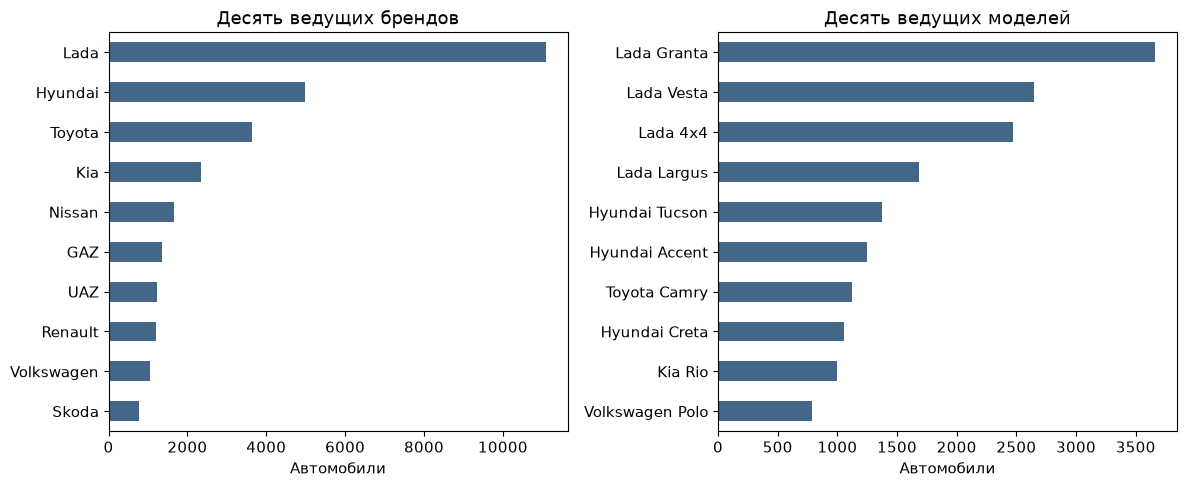

Доля Lada: 31.92 %


In [8]:
brand_sales = market.groupby('brand')['quantity'].sum().sort_values(ascending=False)
model_sales = market.groupby(['brand', 'model'])['quantity'].sum().sort_values(ascending=False)
display(brand_sales.head(10).to_frame('Автомобили'))
display(model_sales.head(10).to_frame('Автомобили'))
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
brand_sales.head(10).sort_values().plot.barh(ax=axes[0], color=blue)
axes[0].set(title='Десять ведущих брендов', xlabel='Автомобили', ylabel='')
model_chart = model_sales.head(10).copy()
model_chart.index = [f'{brand} {model}' for brand, model in model_chart.index]
model_chart.sort_values().plot.barh(ax=axes[1], color=blue)
axes[1].set(title='Десять ведущих моделей', xlabel='Автомобили', ylabel='')
plt.tight_layout()
plt.show()
print('Доля Lada:', round(brand_sales['Lada'] / market.quantity.sum() * 100, 2), '%')

Лидер выборки по количеству — Lada. Для сравнения с автоцентром нужно учитывать разницу в ассортименте: массовые и премиальные бренды решают разные задачи.

,Автомобили
region,
Алматы,7682
Нур-Султан,5682
Атырау,2503
Караганда,2355
Шымкент,2318
Костанай,2212
Усть-Каменогорск,1865
Уральск,1743
Актобе,1422


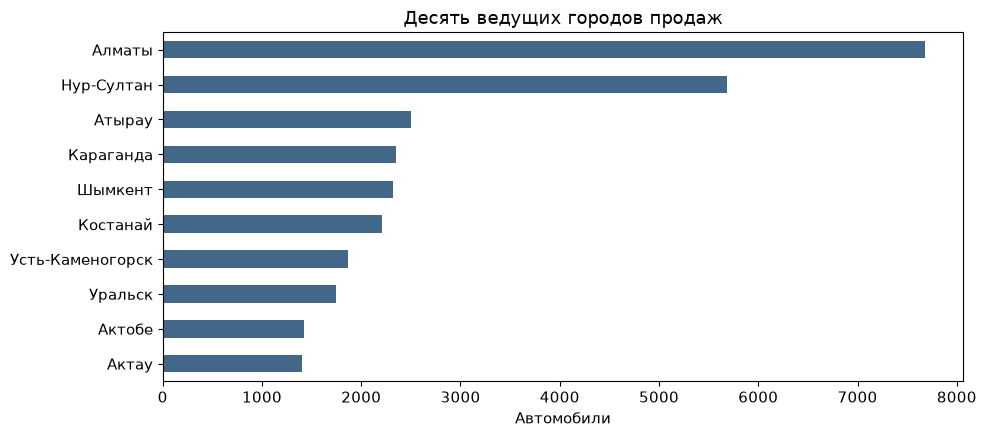

Алматы и Нур-Султан вместе: 38.49 % рынка


In [9]:
region_sales = market.groupby('region')['quantity'].sum().sort_values(ascending=False)
display(region_sales.head(10).to_frame('Автомобили'))
ax = region_sales.head(10).sort_values().plot.barh(color=blue)
ax.set(title='Десять ведущих городов продаж', xlabel='Автомобили', ylabel='')
plt.tight_layout()
plt.show()
print('Алматы и Нур-Султан вместе:', round(region_sales.loc[['Алматы', 'Нур-Султан']].sum() / market.quantity.sum() * 100, 2), '% рынка')

### Топливо и коробка передач

Пропуски показаны отдельной группой. Проценты считаю относительно всего внутреннего рынка, включая неизвестные характеристики.

,Автомобили,"Доля, %"
fuel_type,,
F,30879,88.92
Неизвестно,2925,8.42
D,903,2.60
HYB,14,0.04
E,4,0.01


,Автомобили,"Доля, %"
transmission,,
Автомат,17862,51.44
Механика,13904,40.04
Неизвестно,2959,8.52


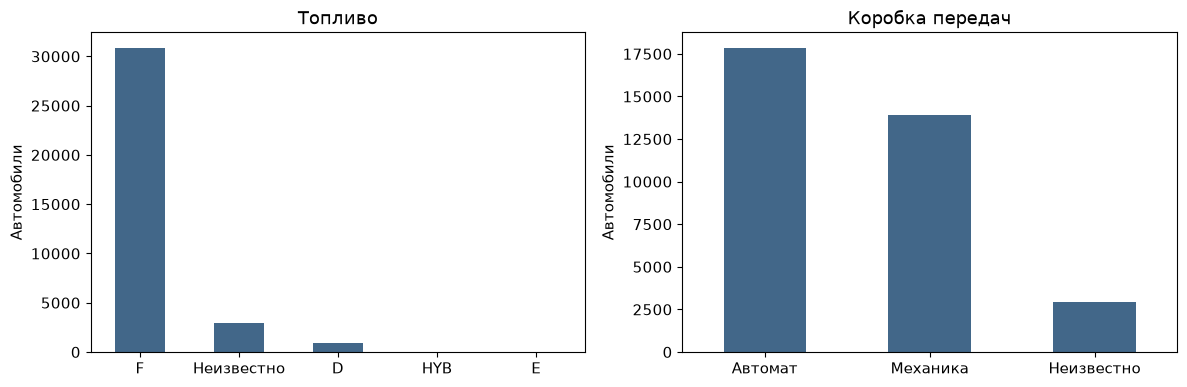

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for column, axis, title in [('fuel_type', axes[0], 'Топливо'), ('transmission', axes[1], 'Коробка передач')]:
    groups = market[column].astype('string').fillna('Неизвестно')
    table = market.groupby(groups)['quantity'].sum().sort_values(ascending=False)
    display(pd.DataFrame({'Автомобили': table, 'Доля, %': table / market.quantity.sum() * 100}))
    table.plot.bar(ax=axis, color=blue, rot=0)
    axis.set(title=title, xlabel='', ylabel='Автомобили')
plt.tight_layout()
plt.show()

Бензиновые автомобили преобладают. Среди известных коробок автоматических больше, чем механических. Долю каждой категории следует читать вместе с группой неизвестных значений.

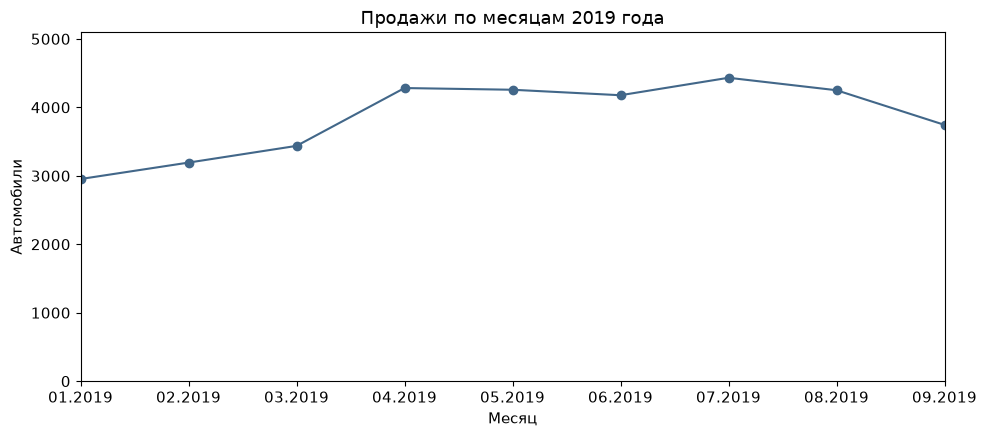

,Автомобили
sale_date,
2019-01-31,2953
2019-02-28,3193
2019-03-31,3437
2019-04-30,4282
2019-05-31,4257
2019-06-30,4177
2019-07-31,4432
2019-08-31,4250
2019-09-30,3744


Максимум: 07.2019 4432 автомобиля


In [11]:
monthly = market.groupby('sale_date')['quantity'].sum()
ax = monthly.plot(marker='o', color=blue)
ax.set(title='Продажи по месяцам 2019 года', xlabel='Месяц', ylabel='Автомобили')
ax.set_xticks(monthly.index)
ax.set_xticklabels(monthly.index.strftime('%m.%Y'))
ax.set_ylim(0, monthly.max() * 1.15)
plt.tight_layout()
plt.show()
display(monthly.to_frame('Автомобили'))
print('Максимум:', monthly.idxmax().strftime('%m.%Y'), monthly.max(), 'автомобиля')

Продажи выросли от января к летним месяцам, в сентябре снизились. Пик — июль. Без данных за другие годы и последний квартал нельзя отделить сезонность от других изменений.

### Связь цены и объёма двигателя

Одна точка — строка исходной выборки после очистки. На графике только легковые автомобили и внедорожники с известным положительным объёмом. Массовость продаж точка не показывает.

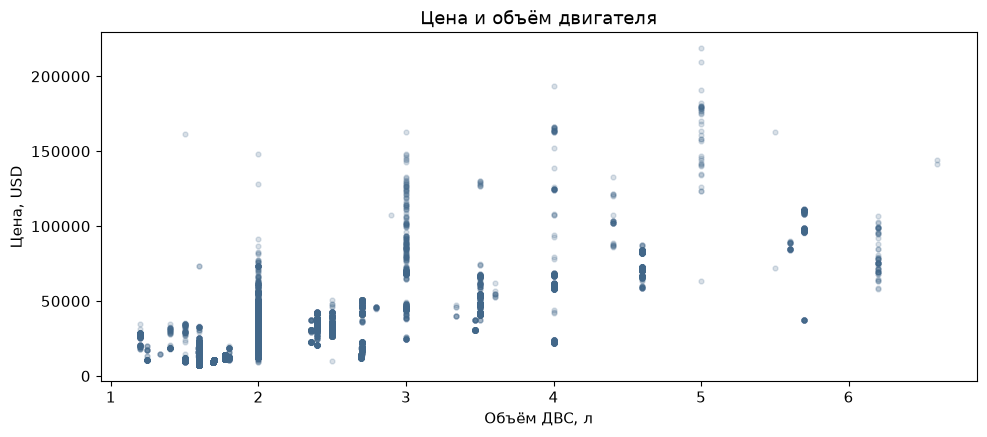

Корреляция по строкам: 0.81


In [12]:
passenger = sales[sales.segment_2013.isin(['Легковые автомобили', 'Внедорожники']) & sales.engine_volume.gt(0)]
ax = passenger.plot.scatter(x='engine_volume', y='price_usd', alpha=0.2, s=12, color=blue)
ax.set(title='Цена и объём двигателя', xlabel='Объём ДВС, л', ylabel='Цена, USD')
plt.tight_layout()
plt.show()
print('Корреляция по строкам:', round(passenger['engine_volume'].corr(passenger['price_usd']), 2))

У автомобилей с большим двигателем часто выше цена, но разброс заметный. На цену влияют также бренд, класс и комплектация. График не доказывает причинную связь.

## 4 Положение Меркур Авто

In [13]:
kpi = pd.DataFrame({
    'Рынок': [market.quantity.sum(), market.revenue_usd.sum(), market.revenue_usd.sum() / market.quantity.sum()],
    'Меркур Авто': [mercur.quantity.sum(), mercur.revenue_usd.sum(), mercur.revenue_usd.sum() / mercur.quantity.sum()],
}, index=['Автомобили с учётом возврата', 'Выручка, USD', 'Выручка на автомобиль, USD'])
display(kpi)
print('Доля по количеству:', round(mercur.quantity.sum() / market.quantity.sum() * 100, 2), '%')
print('Доля по выручке:', round(mercur.revenue_usd.sum() / market.revenue_usd.sum() * 100, 2), '%')
print('Превышение среднего чека рынка:', round((kpi.loc['Выручка на автомобиль, USD', 'Меркур Авто'] / kpi.loc['Выручка на автомобиль, USD', 'Рынок'] - 1) * 100, 2), '%')

,Рынок,Меркур Авто
Автомобили с учётом возврата,"34,725.00",394.00
"Выручка, USD","801,697,865.97","15,121,529.04"
"Выручка на автомобиль, USD","23,087.05","38,379.52"


Доля по количеству: 1.13 %
Доля по выручке: 1.89 %
Превышение среднего чека рынка: 66.24 %


### Доли в брендах и регионах

Доля в бренде — количество автомобилей «Меркур Авто» этой марки, делённое на продажи этой марки на внутреннем рынке. Для городов и сегментов использую такой же знаменатель. Значения 100% означают все записи соответствующего бренда в этой выборке.

In [14]:
def share_table(column):
    total = market.groupby(column, observed=True)['quantity'].sum()
    center = mercur.groupby(column, observed=True)['quantity'].sum()
    result = pd.DataFrame({'Рынок, авто': total, 'Меркур, авто': center}).fillna(0)
    result['Доля Меркур, %'] = result['Меркур, авто'] / result['Рынок, авто'] * 100
    result['В продажах Меркур, %'] = result['Меркур, авто'] / mercur.quantity.sum() * 100
    return result.sort_values('Меркур, авто', ascending=False)

display(share_table('brand').query('`Меркур, авто` > 0'))
display(share_table('region').head(10))

,"Рынок, авто","Меркур, авто","Доля Меркур, %","В продажах Меркур, %"
brand,,,,
Volkswagen,1048,294,28.05,74.62
Porsche,52,52,100.00,13.20
Audi,48,48,100.00,12.18


,"Рынок, авто","Меркур, авто","Доля Меркур, %","В продажах Меркур, %"
region,,,,
Алматы,7682,251,3.27,63.71
Нур-Султан,5682,51,0.90,12.94
Атырау,2503,43,1.72,10.91
Караганда,2355,21,0.89,5.33
Костанай,2212,14,0.63,3.55
Уральск,1743,14,0.80,3.55
Актобе,1422,0,0.00,0.00
Зыряновск,1,0,0.00,0.00
Актау,1400,0,0.00,0.00


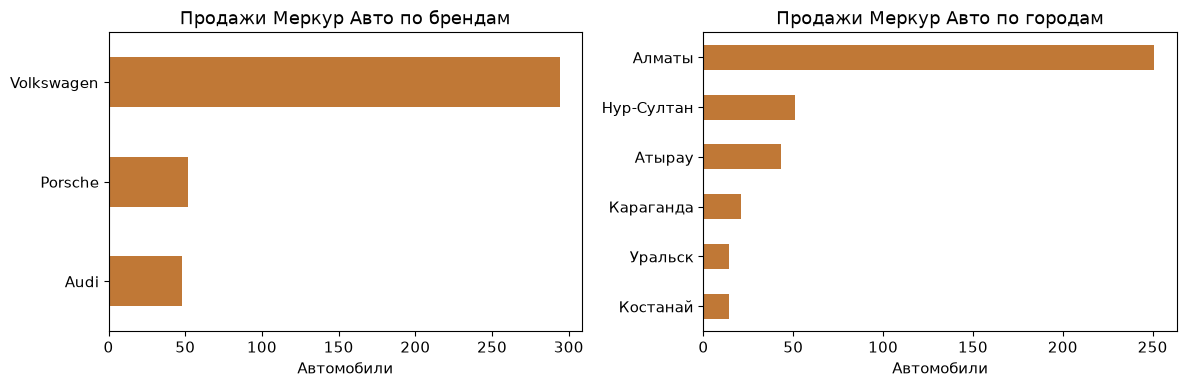

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
mercur.groupby('brand')['quantity'].sum().sort_values().plot.barh(ax=axes[0], color=orange)
axes[0].set(title='Продажи Меркур Авто по брендам', xlabel='Автомобили', ylabel='')
mercur.groupby('region')['quantity'].sum().sort_values().plot.barh(ax=axes[1], color=orange)
axes[1].set(title='Продажи Меркур Авто по городам', xlabel='Автомобили', ylabel='')
plt.tight_layout()
plt.show()

### Сегменты и структура продаж

,"Рынок, авто","Меркур, авто","Доля Меркур, %","В продажах Меркур, %"
segment_2013,,,,
Легковые автомобили,15008,234,1.56,59.39
Внедорожники,14047,145,1.03,36.80
Коммерческие автомобили,3487,8,0.23,2.03
Минивэны,1798,5,0.28,1.27
Пикапы,385,2,0.52,0.51


,"Рынок, авто","Меркур, авто","Доля Меркур, %","В продажах Меркур, %"
class_2013,,,,
B класс,11046,202,1.83,51.27
Полноразмерные SUV,1999,67,3.35,17.01
Компактные SUV,4389,67,1.53,17.01
F класс,45,13,28.89,3.30
Среднеразмерные SUV,2800,11,0.39,2.79
E класс,201,9,4.48,2.28
Микроавтобусы,396,8,2.02,2.03
C класс,1926,5,0.26,1.27
Полноразмерный Минивэн,44,5,11.36,1.27


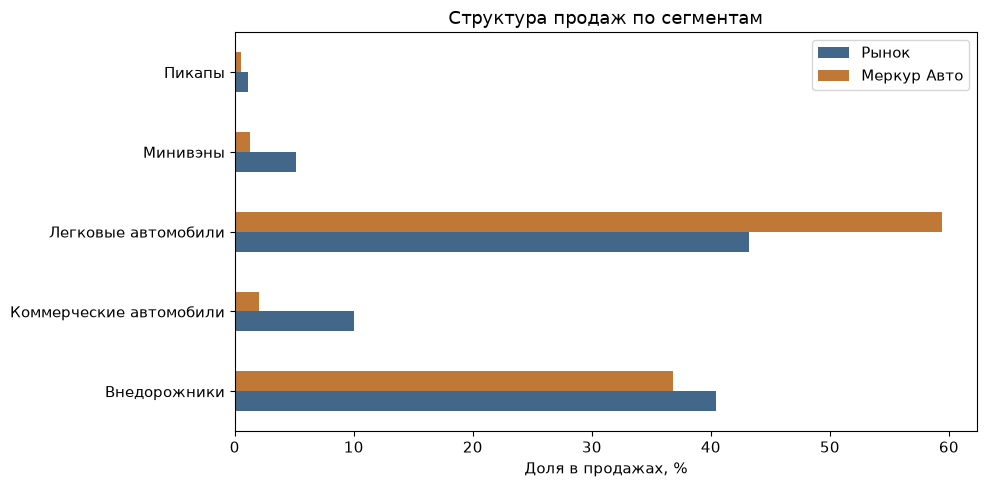

In [16]:
display(share_table('segment_2013'))
display(share_table('class_2013').head(15))
structure = pd.DataFrame({
    'Рынок': market.groupby('segment_2013', observed=True)['quantity'].sum() / market.quantity.sum() * 100,
    'Меркур Авто': mercur.groupby('segment_2013', observed=True)['quantity'].sum() / mercur.quantity.sum() * 100,
}).fillna(0)
ax = structure.plot.barh(color=[blue, orange], figsize=(10, 5))
ax.set(title='Структура продаж по сегментам', xlabel='Доля в продажах, %', ylabel='')
plt.tight_layout()
plt.show()

В продажах «Меркур Авто» больше доля легковых автомобилей. Внедорожники составляют около 37% его объёма против 40% рынка. Небольшой разрыв сам по себе не доказывает упущенный спрос: для решения нужны данные по конкретным моделям и марже.

## 5 Выводы

Внутренний рынок выборки — 34 725 автомобилей с учётом возврата и 801,70 млн долларов выручки. Ведущие бренды — Lada, Hyundai и Toyota. Основные города продаж — Алматы и Нур-Султан.

«Меркур Авто» продал 394 автомобиля на 15,12 млн долларов. Доля по количеству — 1,13%, по выручке — 1,89%. Средняя выручка на автомобиль составила 38 380 долларов против 23 087 на рынке. Это связано в том числе с более дорогим ассортиментом и не показывает прибыльность.

Volkswagen даёт 294 автомобиля, Porsche — 52, Audi — 48. В Алматы продан 251 автомобиль, около 64% объёма центра. Сильная сторона — присутствие в дорогом сегменте. Зависимость от Volkswagen по объёму и Алматы по географии ограничивает устойчивость продаж. Возможное направление роста — проверить спрос на модели Volkswagen за пределами Алматы, сопоставив его с расходами на расширение.

Ограничения: только девять месяцев; неизвестные характеристики сохранены; нет идентификаторов продаж. Полные дубликаты удалены по условию задания, но одинаковые строки могут описывать разные реальные операции. Поэтому результат характеризует очищенную учебную выборку, а не независимо подтверждённый объём рынка страны.

Итоговые файлы: `autokz2019_clean.csv`, [отчёт](report.md), [скрипт очистки](clean_data.py).